# Modélisation — Prédiction de la consommation électrique (EDF / RTE)

**Pipeline** :
1. Feature engineering (cyclicité, lags, rolling, jours fériés)
2. Split temporel train / validation / test
3. Modèles : Baseline · Ridge · Random Forest · XGBoost
4. Tracking MLflow
5. Évaluation & comparaison

In [18]:
# Diagnostic — vérifie que le bon Python est utilisé
import sys
print(sys.executable)
# Doit contenir : .../projet-edf/.venv/bin/python

/Users/pol/Documents/VSCode/projet-edf/.venv/bin/python


## 0. Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import time  # mesure du temps d'apprentissage (exigence TP)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
import mlflow

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (14, 5)

print('MLflow', mlflow.__version__)
print('Librairies chargées.')
# Se placer à la racine du projet, quelle que soit la cwd Jupyter
import os
from pathlib import Path
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == 'notebooks' else _here
os.chdir(PROJECT_ROOT)
print(f'Working dir : {PROJECT_ROOT}')


## 1. Chargement des données

In [20]:
df = pd.read_csv('data/processed/daily_consumption.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Période : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Shape   : {df.shape}')
df[['Date', 'conso_mean_mw']].tail()

Période : 2012-01-01 → 2024-12-31
Shape   : (4749, 25)


,Date,conso_mean_mw
4744,2024-12-27,62468.979167
4745,2024-12-28,63059.770833
4746,2024-12-29,61668.312500
4747,2024-12-30,65399.312500
4748,2024-12-31,66072.687500


## 2. Feature Engineering

### 2.1 Jours fériés français

In [21]:
# Jours fériés français (sans dépendance externe)
def french_holidays(years):
    """Retourne un set de dates correspondant aux jours fériés fixes + Pâques."""
    from datetime import date, timedelta

    def easter(year):
        """Algorithme de Butcher pour la date de Pâques."""
        a = year % 19
        b, c = divmod(year, 100)
        d, e = divmod(b, 4)
        f = (b + 8) // 25
        g = (b - f + 1) // 3
        h = (19 * a + b - d - g + 15) % 30
        i, k = divmod(c, 4)
        l = (32 + 2 * e + 2 * i - h - k) % 7
        m = (a + 11 * h + 22 * l) // 451
        month, day = divmod(114 + h + l - 7 * m, 31)
        return date(year, month, day + 1)

    holidays = set()
    for y in years:
        e = easter(y)
        holidays |= {
            date(y, 1, 1),   # Jour de l'an
            e + timedelta(1), # Lundi de Pâques
            date(y, 5, 1),   # Fête du Travail
            date(y, 5, 8),   # Victoire 1945
            e + timedelta(39), # Ascension
            e + timedelta(50), # Lundi de Pentecôte
            date(y, 7, 14),  # Fête Nationale
            date(y, 8, 15),  # Assomption
            date(y, 11, 1),  # Toussaint
            date(y, 11, 11), # Armistice
            date(y, 12, 25), # Noël
        }
    return holidays

years = df['Date'].dt.year.unique()
holidays = french_holidays(years)
df['is_holiday'] = df['Date'].dt.date.apply(lambda d: int(d in holidays))

print(f"Jours fériés couverts (ex. 2023) : {sorted(d for d in holidays if d.year == 2023)}")

Jours fériés couverts (ex. 2023) : [datetime.date(2023, 1, 1), datetime.date(2023, 4, 10), datetime.date(2023, 5, 1), datetime.date(2023, 5, 8), datetime.date(2023, 5, 18), datetime.date(2023, 5, 29), datetime.date(2023, 7, 14), datetime.date(2023, 8, 15), datetime.date(2023, 11, 1), datetime.date(2023, 11, 11), datetime.date(2023, 12, 25)]


### 2.2 Encodage cyclique

In [22]:
df['month_sin']   = np.sin(2 * np.pi * df['month']     / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month']     / 12)
df['doy_sin']     = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['doy_cos']     = np.cos(2 * np.pi * df['dayofyear'] / 365)
df['dow_sin']     = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['dayofweek'] / 7)

print('Encodage cyclique OK.')

Encodage cyclique OK.


### 2.3 Lag features & rolling means

In [23]:
target = 'conso_mean_mw'

# Lags
for lag in [1, 7, 14, 30, 365]:
    df[f'lag_{lag}'] = df[target].shift(lag)

# Rolling means (sur la conso shiftée de 1 jour pour éviter la fuite)
df['roll_7']  = df[target].shift(1).rolling(7,  min_periods=1).mean()
df['roll_30'] = df[target].shift(1).rolling(30, min_periods=1).mean()

# Prévision J-1 RTE comme feature (baseline externe)
if 'prevision_j1_mean' in df.columns:
    df['prevision_j1_mean'] = df['prevision_j1_mean'].fillna(df['lag_1'])

# Supprimer les lignes avec NaN (dues aux lags)
df_feat = df.dropna().copy()
print(f'Dataset après feature engineering : {df_feat.shape[0]} jours')
df_feat[['Date', target, 'lag_1', 'lag_7', 'lag_365', 'roll_7', 'roll_30']].head()

Dataset après feature engineering : 4384 jours


,Date,conso_mean_mw,lag_1,lag_7,lag_365,roll_7,roll_30
365,2012-12-31,58227.020833,55162.770833,55316.500000,51491.500000,56043.839286,66566.091667
366,2013-01-01,54546.750000,58227.020833,50577.770833,60683.645833,56459.627976,66229.931250
367,2013-01-02,64501.812500,54546.750000,57287.250000,67762.104167,57026.625000,65867.595139
368,2013-01-03,66651.062500,64501.812500,59269.250000,68029.229167,58057.276786,65628.486806
369,2013-01-04,65247.750000,66651.062500,58998.291667,69157.395833,59111.821429,65470.347222


## 3. Split temporel

| Période | Usage |
|---------|-------|
| 2013–2021 | Train |
| 2022 | Validation |
| 2023–2024 | Test |

In [24]:
FEATURES = [
    # Temporel cyclique
    'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos',
    # Catégoriel
    'is_weekend', 'is_holiday',
    # Lags
    'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365',
    # Rolling
    'roll_7', 'roll_30',
]

TARGET = 'conso_mean_mw'

train = df_feat[df_feat['Date'].dt.year <= 2021]
val   = df_feat[df_feat['Date'].dt.year == 2022]
test  = df_feat[df_feat['Date'].dt.year >= 2023]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train : {len(train)} jours ({train["Date"].min().date()} → {train["Date"].max().date()})')
print(f'Val   : {len(val)} jours ({val["Date"].min().date()} → {val["Date"].max().date()})')
print(f'Test  : {len(test)} jours ({test["Date"].min().date()} → {test["Date"].max().date()})')

Train : 3288 jours (2012-12-31 → 2021-12-31)
Val   : 365 jours (2022-01-01 → 2022-12-31)
Test  : 731 jours (2023-01-01 → 2024-12-31)


## 4. Fonctions utilitaires

In [ ]:
def evaluate(y_true, y_pred, label='', training_time=None):
    """Calcule RMSE / MAPE / R² et retourne un dict de métriques.

    Si `training_time` (en secondes) est fourni, il est inclus dans le dict
    et affiché. Cette métrique est exigée par le cahier des charges MSPR EDF
    au même titre que R², RMSE et MAPE.
    """
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)

    msg = f'[{label}]  RMSE={rmse:.1f} MW  |  MAPE={mape:.2f}%  |  R²={r2:.4f}'
    metrics = {'rmse': rmse, 'mape': mape, 'r2': r2}
    if training_time is not None:
        msg += f'  |  fit={training_time:.2f}s'
        metrics['training_time'] = training_time
    if label:
        print(msg)
    return metrics


def plot_predictions(dates, y_true, y_pred, title):
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)

    # Série temporelle
    axes[0].plot(dates, y_true.values,  label='Réel',       color='steelblue', lw=1.5)
    axes[0].plot(dates, y_pred,         label='Prédit',     color='firebrick', lw=1.2, alpha=0.8)
    axes[0].set_title(title, fontweight='bold')
    axes[0].set_ylabel('MW moyen journalier')
    axes[0].legend()
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Résidus
    residuals = y_true.values - y_pred
    axes[1].bar(dates, residuals, color=np.where(residuals > 0, 'steelblue', 'coral'),
                width=1, alpha=0.7)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_ylabel('Résidu (MW)')
    axes[1].set_title('Résidus (réel − prédit)', fontweight='bold')
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    plt.show()

results = {}  # stocke les métriques test de chaque modèle
print('Utilitaires définis.')


## 5. Modèles

### 5.1 Baseline — Persistance lag-1 et lag-7

In [ ]:
# Baseline lag-1 : on prédit J avec la conso de J-1 (aucun apprentissage)
metrics_lag1 = evaluate(y_test, test['lag_1'], 'Baseline lag-1 (test)', training_time=0.0)
results['Baseline lag-1'] = metrics_lag1

# Baseline lag-7 : même jour la semaine dernière
metrics_lag7 = evaluate(y_test, test['lag_7'], 'Baseline lag-7 (test)', training_time=0.0)
results['Baseline lag-7'] = metrics_lag7

# Prévision RTE J-1 si disponible (benchmark externe, pas d'apprentissage non plus)
if 'prevision_j1_mean' in test.columns:
    metrics_rte = evaluate(y_test, test['prevision_j1_mean'], 'Benchmark RTE J-1 (test)',
                           training_time=0.0)
    results['Benchmark RTE J-1'] = metrics_rte


### 5.2 Ridge Regression

In [ ]:
with mlflow.start_run(run_name='Ridge'):
    pipe_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=10.0))
    ])
    t0 = time.perf_counter()
    pipe_ridge.fit(X_train, y_train)
    fit_time_ridge = time.perf_counter() - t0

    pred_val_ridge  = pipe_ridge.predict(X_val)
    pred_test_ridge = pipe_ridge.predict(X_test)

    m_val  = evaluate(y_val,  pred_val_ridge,  'Ridge val')
    m_test = evaluate(y_test, pred_test_ridge, 'Ridge test', training_time=fit_time_ridge)

    mlflow.log_params({'alpha': 10.0, 'model': 'Ridge'})
    mlflow.log_metrics({f'val_{k}': v for k, v in m_val.items() if k != 'training_time'})
    mlflow.log_metrics({f'test_{k}': v for k, v in m_test.items()})
    mlflow.sklearn.log_model(pipe_ridge, 'ridge_model')

results['Ridge'] = m_test

plot_predictions(test['Date'], y_test, pred_test_ridge, 'Ridge — Test 2023–2024')


### 5.3 Random Forest

In [ ]:
RF_PARAMS = {
    'n_estimators': 300,
    'max_depth': 12,
    'min_samples_leaf': 5,
    'n_jobs': -1,
    'random_state': 42,
}

with mlflow.start_run(run_name='RandomForest'):
    rf = RandomForestRegressor(**RF_PARAMS)
    t0 = time.perf_counter()
    rf.fit(X_train, y_train)
    fit_time_rf = time.perf_counter() - t0

    pred_val_rf  = rf.predict(X_val)
    pred_test_rf = rf.predict(X_test)

    m_val  = evaluate(y_val,  pred_val_rf,  'RF val')
    m_test = evaluate(y_test, pred_test_rf, 'RF test', training_time=fit_time_rf)

    mlflow.log_params(RF_PARAMS)
    mlflow.log_metrics({f'val_{k}': v for k, v in m_val.items() if k != 'training_time'})
    mlflow.log_metrics({f'test_{k}': v for k, v in m_test.items()})
    mlflow.sklearn.log_model(rf, 'rf_model')

results['RandomForest'] = m_test

plot_predictions(test['Date'], y_test, pred_test_rf, 'Random Forest — Test 2023–2024')


### 5.4 XGBoost

In [ ]:
XGB_PARAMS = {
    'n_estimators':      500,
    'learning_rate':     0.05,
    'max_depth':         6,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'random_state':      42,
    'n_jobs':            -1,
    'early_stopping_rounds': 30,
    'eval_metric':       'rmse',
}

with mlflow.start_run(run_name='XGBoost'):
    xgb_model = xgb.XGBRegressor(**XGB_PARAMS)
    t0 = time.perf_counter()
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=50
    )
    fit_time_xgb = time.perf_counter() - t0

    pred_val_xgb  = xgb_model.predict(X_val)
    pred_test_xgb = xgb_model.predict(X_test)

    m_val  = evaluate(y_val,  pred_val_xgb,  'XGBoost val')
    m_test = evaluate(y_test, pred_test_xgb, 'XGBoost test', training_time=fit_time_xgb)

    mlflow.log_params({k: v for k, v in XGB_PARAMS.items() if k != 'early_stopping_rounds'})
    mlflow.log_param('early_stopping_rounds', XGB_PARAMS['early_stopping_rounds'])
    mlflow.log_metrics({f'val_{k}': v for k, v in m_val.items() if k != 'training_time'})
    mlflow.log_metrics({f'test_{k}': v for k, v in m_test.items()})
    mlflow.xgboost.log_model(xgb_model, 'xgb_model')

results['XGBoost'] = m_test

plot_predictions(test['Date'], y_test, pred_test_xgb, 'XGBoost — Test 2023–2024')


### 5.5 Importance des features (XGBoost)

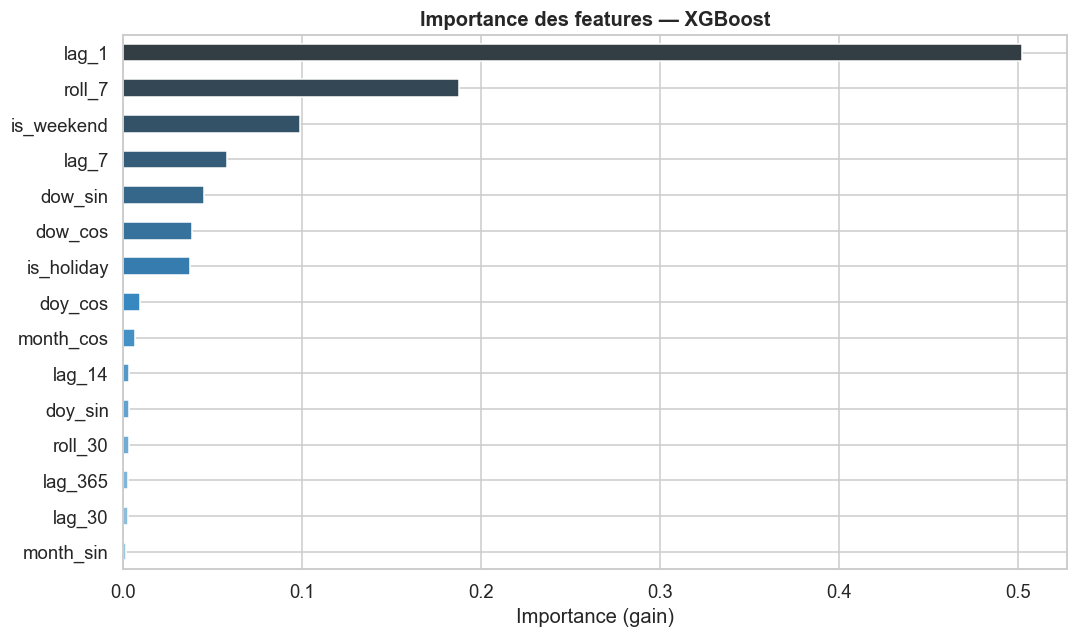

In [30]:
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Blues_d', len(importances))
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Importance des features — XGBoost', fontweight='bold')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

### 5.5 K-Nearest Neighbors (KNN)

Modèle demandé explicitement par le cahier des charges MSPR EDF. KNN prédit la consommation d'un jour comme la moyenne des *k* jours historiques les plus similaires (en termes de features normalisées). Très rapide à entraîner (lazy learner), plus lent à inférer.

In [ ]:
KNN_PARAMS = {
    'n_neighbors': 15,
    'weights': 'distance',   # voisins les plus proches pondérés par 1/distance
    'p': 2,                  # distance euclidienne
    'n_jobs': -1,
}

with mlflow.start_run(run_name='KNN'):
    pipe_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  KNeighborsRegressor(**KNN_PARAMS)),
    ])
    t0 = time.perf_counter()
    pipe_knn.fit(X_train, y_train)
    fit_time_knn = time.perf_counter() - t0

    pred_val_knn  = pipe_knn.predict(X_val)
    pred_test_knn = pipe_knn.predict(X_test)

    m_val  = evaluate(y_val,  pred_val_knn,  'KNN val')
    m_test = evaluate(y_test, pred_test_knn, 'KNN test', training_time=fit_time_knn)

    mlflow.log_params(KNN_PARAMS)
    mlflow.log_metrics({f'val_{k}': v for k, v in m_val.items() if k != 'training_time'})
    mlflow.log_metrics({f'test_{k}': v for k, v in m_test.items()})
    mlflow.sklearn.log_model(pipe_knn, 'knn_model')

results['KNN'] = m_test

plot_predictions(test['Date'], y_test, pred_test_knn, 'KNN — Test 2023–2024')


### 5.6 Arbre de Décision (CART)

Modèle demandé explicitement par le cahier des charges MSPR EDF. Sert de référence *interprétable* pour comprendre les règles apprises (pas de forêt, un seul arbre). Sujet au surajustement : on limite `max_depth` et `min_samples_leaf` pour régulariser.

In [ ]:
DT_PARAMS = {
    'max_depth': 10,
    'min_samples_leaf': 10,
    'random_state': 42,
}

with mlflow.start_run(run_name='DecisionTree'):
    dt = DecisionTreeRegressor(**DT_PARAMS)
    t0 = time.perf_counter()
    dt.fit(X_train, y_train)
    fit_time_dt = time.perf_counter() - t0

    pred_val_dt  = dt.predict(X_val)
    pred_test_dt = dt.predict(X_test)

    m_val  = evaluate(y_val,  pred_val_dt,  'DT val')
    m_test = evaluate(y_test, pred_test_dt, 'DT test', training_time=fit_time_dt)

    mlflow.log_params(DT_PARAMS)
    mlflow.log_metrics({f'val_{k}': v for k, v in m_val.items() if k != 'training_time'})
    mlflow.log_metrics({f'test_{k}': v for k, v in m_test.items()})
    mlflow.sklearn.log_model(dt, 'dt_model')

results['DecisionTree'] = m_test

plot_predictions(test['Date'], y_test, pred_test_dt, 'Arbre de décision — Test 2023–2024')


### 5.7 Réseau de neurones à fonctions de bases radiales (RBF)

Modèle demandé explicitement par le cahier des charges MSPR EDF (« réseaux de neurones artificiels à bases de fonctions de bases radiales »).

**Architecture à 2 couches** :

$$\hat{y}(x) = \sum_{k=1}^{K} w_k \cdot \phi_k(x) + b$$

où $\phi_k(x) = \exp\!\left(-\dfrac{\|x - c_k\|^2}{2\sigma^2}\right)$ est la *k*-ème fonction gaussienne centrée sur $c_k$.

**Apprentissage** :
1. Les centres $c_k$ sont choisis par K-Means sur X_train (couche non-supervisée).
2. Les poids $w_k$ et $b$ sont résolus par moindres carrés régularisés (ridge) sur la matrice d'activations $\Phi$ — équivalent analytique d'une couche de sortie linéaire entraînée à convergence.

Avantage pour EDF : apprentissage rapide, bonne interpolation locale des cycles journaliers/hebdomadaires, peu d'hyperparamètres ($K$, $\sigma$).

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin


class RBFNetwork(RegressorMixin, BaseEstimator):
    """RBF Network minimaliste : K-Means pour les centres, ridge pour la sortie."""

    def __init__(self, n_centers=50, sigma=None, ridge=1e-2, random_state=42):
        self.n_centers = n_centers
        self.sigma = sigma
        self.ridge = ridge
        self.random_state = random_state

    def _activations(self, X):
        diff = X[:, None, :] - self.centers_[None, :, :]
        d2 = (diff ** 2).sum(axis=-1)
        return np.exp(-d2 / (2.0 * self.sigma_ ** 2))

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        # 1. Centres par K-Means (couche RBF non supervisée)
        km = KMeans(n_clusters=self.n_centers, n_init=10,
                    random_state=self.random_state)
        km.fit(X)
        self.centers_ = km.cluster_centers_

        # 2. Sigma = distance moyenne entre centres / sqrt(2K) si non fourni
        if self.sigma is None:
            diff = self.centers_[:, None, :] - self.centers_[None, :, :]
            dmat = np.sqrt((diff ** 2).sum(-1))
            iu = np.triu_indices(self.n_centers, k=1)
            self.sigma_ = float(dmat[iu].mean()) / np.sqrt(2 * self.n_centers)
            if self.sigma_ <= 0:
                self.sigma_ = 1.0
        else:
            self.sigma_ = float(self.sigma)

        # 3. Poids de sortie par moindres carrés régularisés (ridge)
        Phi = self._activations(X)
        Phi_b = np.column_stack([Phi, np.ones(len(X))])
        A = Phi_b.T @ Phi_b + self.ridge * np.eye(Phi_b.shape[1])
        theta = np.linalg.solve(A, Phi_b.T @ y)
        self.w_ = theta[:-1]
        self.b_ = float(theta[-1])
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self._activations(X) @ self.w_ + self.b_


RBF_PARAMS = {'n_centers': 60, 'ridge': 1e-2, 'random_state': 42}

with mlflow.start_run(run_name='RBF'):
    pipe_rbf = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RBFNetwork(**RBF_PARAMS)),
    ])
    t0 = time.perf_counter()
    pipe_rbf.fit(X_train, y_train)
    fit_time_rbf = time.perf_counter() - t0

    pred_val_rbf  = pipe_rbf.predict(X_val)
    pred_test_rbf = pipe_rbf.predict(X_test)

    m_val  = evaluate(y_val,  pred_val_rbf,  'RBF val')
    m_test = evaluate(y_test, pred_test_rbf, 'RBF test', training_time=fit_time_rbf)

    mlflow.log_params(RBF_PARAMS)
    mlflow.log_metric('sigma', pipe_rbf.named_steps['model'].sigma_)
    mlflow.log_metrics({f'val_{k}': v for k, v in m_val.items() if k != 'training_time'})
    mlflow.log_metrics({f'test_{k}': v for k, v in m_test.items()})

results['RBF'] = m_test

plot_predictions(test['Date'], y_test, pred_test_rbf, 'RBF Network — Test 2023–2024')


## 6. Comparaison des modèles

In [ ]:
df_results = pd.DataFrame(results).T
# Trie par RMSE croissant
df_results = df_results.sort_values('rmse')

rename_map = {'rmse': 'RMSE (MW)', 'mape': 'MAPE (%)', 'r2': 'R²',
              'training_time': 'Temps fit (s)'}
df_results = df_results.rename(columns=rename_map)

# Colonnes numériques
num_cols = ['RMSE (MW)', 'MAPE (%)', 'R²', 'Temps fit (s)']
for c in num_cols:
    if c in df_results.columns:
        df_results[c] = df_results[c].astype(float)

styler = (df_results.style
    .format({'RMSE (MW)': '{:.1f}', 'MAPE (%)': '{:.2f}',
             'R²': '{:.4f}', 'Temps fit (s)': '{:.2f}'})
    .background_gradient(subset=['RMSE (MW)'], cmap='RdYlGn_r')
    .background_gradient(subset=['R²'], cmap='RdYlGn')
)
if 'Temps fit (s)' in df_results.columns:
    styler = styler.background_gradient(subset=['Temps fit (s)'], cmap='RdYlGn_r')

display(styler)

# Bar chart RMSE
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(df_results.index, df_results['RMSE (MW)'],
               color=sns.color_palette('RdYlGn_r', len(df_results)))
ax.bar_label(bars, fmt='%.0f MW', padding=5)
ax.set_title('RMSE sur le jeu de test (2023–2024)', fontweight='bold')
ax.set_xlabel('RMSE (MW) — moins c\'est mieux')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Bar chart Temps d'apprentissage
if 'Temps fit (s)' in df_results.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    df_time = df_results.sort_values('Temps fit (s)')
    bars = ax.barh(df_time.index, df_time['Temps fit (s)'],
                   color=sns.color_palette('RdYlGn_r', len(df_time)))
    ax.bar_label(bars, fmt='%.2f s', padding=5)
    ax.set_title("Temps d'apprentissage (secondes)", fontweight='bold')
    ax.set_xlabel("Temps d'apprentissage — moins c'est mieux")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


## 7. Analyse des erreurs du meilleur modèle (XGBoost)

In [32]:
test_eval = test[['Date', 'conso_mean_mw', 'year', 'month', 'dayofweek', 'season']].copy()
test_eval['pred'] = pred_test_xgb
test_eval['error'] = test_eval['conso_mean_mw'] - test_eval['pred']
test_eval['abs_error'] = test_eval['error'].abs()
test_eval['pct_error'] = test_eval['abs_error'] / test_eval['conso_mean_mw'] * 100

print('=== Top 10 pires erreurs ===')
display(test_eval.nlargest(10, 'abs_error')[['Date', 'conso_mean_mw', 'pred', 'error', 'pct_error', 'season']].round(0))

=== Top 10 pires erreurs ===


,Date,conso_mean_mw,pred,error,pct_error,season
4711,2024-11-24,51881.0,60242.0,-8361.0,16.0,Automne
4404,2024-01-22,66849.0,74769.0,-7921.0,12.0,Hiver
4712,2024-11-25,54319.0,61910.0,-7591.0,14.0,Automne
4719,2024-12-02,57849.0,63264.0,-5415.0,9.0,Hiver
4427,2024-02-14,57259.0,62634.0,-5375.0,9.0,Hiver
4723,2024-12-06,59946.0,65318.0,-5372.0,9.0,Hiver
4334,2023-11-13,52224.0,57377.0,-5153.0,10.0,Automne
4406,2024-01-24,59404.0,64509.0,-5105.0,9.0,Hiver
4359,2023-12-08,63421.0,68500.0,-5079.0,8.0,Hiver
4353,2023-12-02,64413.0,59346.0,5067.0,8.0,Hiver


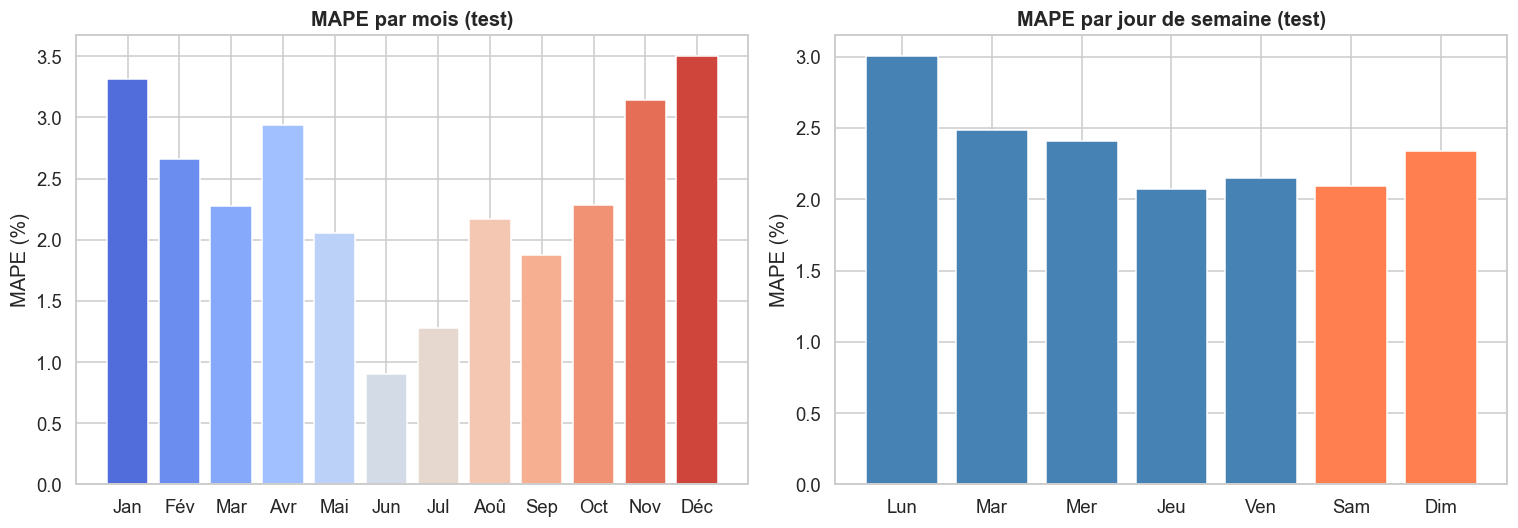

In [33]:
DOW_NAMES = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
MONTH_NAMES = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAPE par mois
mape_month = test_eval.groupby('month')['pct_error'].mean()
axes[0].bar(mape_month.index, mape_month.values,
            color=sns.color_palette('coolwarm', 12))
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(MONTH_NAMES)
axes[0].set_title('MAPE par mois (test)', fontweight='bold')
axes[0].set_ylabel('MAPE (%)')

# MAPE par jour de semaine
mape_dow = test_eval.groupby('dayofweek')['pct_error'].mean()
axes[1].bar(mape_dow.index, mape_dow.values,
            color=['steelblue']*5 + ['coral']*2)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(DOW_NAMES)
axes[1].set_title('MAPE par jour de semaine (test)', fontweight='bold')
axes[1].set_ylabel('MAPE (%)')

plt.tight_layout()
plt.show()

## 8. Sauvegarde du meilleur modèle

In [34]:
import os, json

os.makedirs('models', exist_ok=True)
xgb_model.save_model('models/xgb_best.json')

# Sauvegarder la liste des features
with open('models/features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)

print('Modèle sauvegardé : models/xgb_best.json')
print('Features sauvegardées : models/features.json')
print()
print('=== Métriques finales XGBoost (test 2023–2024) ===')
evaluate(y_test, pred_test_xgb, 'XGBoost')

Modèle sauvegardé : models/xgb_best.json
Features sauvegardées : models/features.json

=== Métriques finales XGBoost (test 2023–2024) ===
[XGBoost]  RMSE=1662.9 MW  |  MAPE=2.37%  |  R²=0.9666


{'rmse': 1662.933440773363,
 'mape': 2.366130292777104,
 'r2': 0.9666135555104822}